In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mysql.connector

db = mysql.connector.connect(
    host = "localhost",
    username = "root",
    password = "12345",
    database = "ecommerce")

cur = db.cursor(buffered=True)

# 1List all unique cities where customers are located.  

In [6]:
# sql query for unique values
query = """ select distinct(customer_city) from customers"""
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data
# show all fetched data
# code run ho par output show na ho usske liye ; use krte h
# data;

# 2. Count the number of orders placed in 2017.

In [9]:
query = """ select count(order_id) from ecommerce.orders where year(order_purchase_timestamp) = 2017; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
"total order placed in 2017 are", data[0][0];

# 3. Find the total sales per category.

In [64]:
# Product Table + Order Item join then apply
# sql query for unique values
query = """ SELECT p.product_category AS category,
round(sum(pay.payment_value),0) as sales
from ecommerce.products as p
inner join ecommerce.order_items as oi
on p.product_id = oi.product_id
inner join ecommerce.payments as pay
on pay.order_id = oi.order_id
group by category; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

# datafrmae me column ke name diye h category or sales aese de sakte h
df = pd.DataFrame(data, columns = ["Category", "Sales"])
df;

,Category,Sales
0,HEALTH BEAUTY,106071880.0
1,sport leisure,89096164.0
2,Cool Stuff,49900672.0
3,computer accessories,101461149.0
4,Watches present,91469867.0
...,...,...
69,Kitchen portable and food coach,277482.0
70,House Comfort 2,109475.0
71,CITTE AND UPHACK FURNITURE,383907.0
72,insurance and services,20769.0


# 4. Calculate the percentage of orders that were paid in installments.

In [28]:
# sql query for unique values
query = """ select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*) from ecommerce.payments; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
"the percentage of orders that were paid in installments is", data[0][0];

# 5. Count the number of customers from each state. 

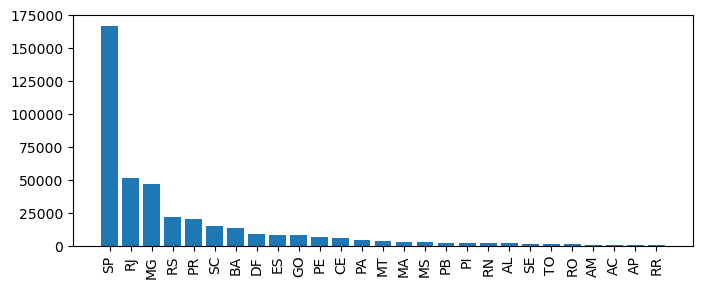

In [42]:
# sql query for unique values
query = """ select customer_state, count(customer_id) from ecommerce.customers group by customer_state; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns=["state","customer_count"])
df = df.sort_values(by = "customer_count", ascending=False)

plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation=90)
plt.show()

# Intermediate Queries
# 1. Calculate the number of orders per month in 2018.

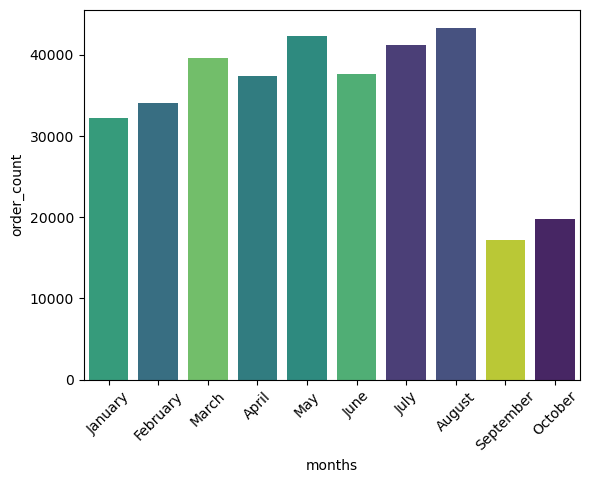

In [57]:
query = """ SELECT monthName(order_purchase_timestamp) as months, count(order_id) as count 
FROM ecommerce.orders where month(order_purchase_timestamp) group by months; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January","February","March","April","May","June","July","August","September","October"]
sns.barplot(x = df["months"],y = df["order_count"], data = df, order = o, hue=df["months"],palette = "viridis")
plt.xticks(rotation = 45)
plt.show()

# 2. Find the average number of products per order, grouped by customer city.

In [63]:
query = """ SELECT c.customer_city, ROUND(AVG(product_count),2) AS avg_products_per_order
FROM (SELECT o.order_id, o.customer_id, COUNT(oi.product_id) AS product_count
FROM ecommerce.orders as o 
inner join ecommerce.order_items as oi
ON o.order_id = oi.order_id
GROUP BY o.order_id, o.customer_id) AS order_products
JOIN ecommerce.customers c
ON order_products.customer_id = c.customer_id
GROUP BY c.customer_city order by avg_products_per_order desc; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "customer_city","avg_products_per_order"])
df.head(10);

# 3. Calculate the percentage of total revenue contributed by each product category.

In [68]:
query = """ SELECT p.product_category AS product_category, 
ROUND(SUM(oi.price) / (SELECT SUM(price) FROM ecommerce.order_items) * 100,2) AS revenue_percentage
FROM ecommerce.products p
JOIN ecommerce.order_items oi
ON p.product_id = oi.product_id
GROUP BY p.product_category
ORDER BY revenue_percentage DESC; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "product_category","revenue_percentage"])
df.head(10);

# 4. Identify the correlation between product price and the number of times a product has been purchased.

In [74]:
query = """ SELECT p.product_category, Round(AVG(oi.price),2) AS product_price, 
COUNT(oi.product_id) AS purchase_count
FROM ecommerce.products p
JOIN ecommerce.order_items oi
ON p.product_id = oi.product_id
GROUP BY p.product_category ORDER BY purchase_count DESC; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "product_category","product_price","purchase_count"])
df.head(10)

arr1 = df["purchase_count"]
arr2 = df["product_price"]

np.corrcoef([arr1,arr2]);

# 5. Calculate the total revenue generated by each seller, and rank them by revenue.

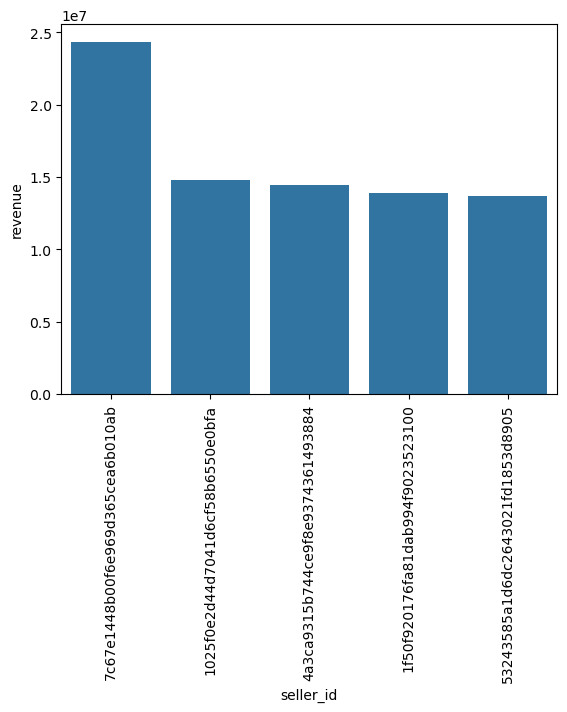

In [80]:
query = """ SELECT *, DENSE_RANK() OVER (ORDER BY revenue DESC) AS seller_rank
FROM (SELECT s.seller_id, ROUND(SUM(pay.payment_value),2) AS revenue FROM ecommerce.sellers s
    JOIN ecommerce.order_items oi
    ON s.seller_id = oi.seller_id
    JOIN ecommerce.payments pay
    ON oi.order_id = pay.order_id
    GROUP BY s.seller_id
) AS seller_revenue
ORDER BY revenue DESC LIMIT 5; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "seller_id","revenue","seller_rank"])

sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Advanced Queries
# 1. Calculate the moving average of order values for each customer over their order history.

In [82]:
query = """ select customer_id, order_purchase_timestamp, payment_value,
round(avg(payment_value) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row),2) as mov_avg
from
(select o.customer_id ,o.order_purchase_timestamp, pay.payment_value as payment_value from ecommerce.payments as pay
inner join ecommerce.orders as o
on pay.order_id = o.order_id) as a; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "customer_id","order_purchase_timestamp","payment","moving_avg"])
df;

# 2. Calculate the cumulative sales per month for each year.

In [85]:
query = """ select years,months,payment, round(sum(payment)
over(order by years, months),0) as cumulative_sales from
(select year(o.order_purchase_timestamp) as years,
month(o.order_purchase_timestamp) as months,
round(sum(pay.payment_value),2) as payment
from ecommerce.orders as o 
inner join ecommerce.payments as pay
on pay.order_id = o.order_id
group by years, months order by years, months) as a; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "years","months","payment","cumulative_sales"])
df;

# 3. Calculate the year-over-year growth rate of total sales.

In [98]:
# YoY Growth % = ((Current Year Sales - Previous Year Sales) / Previous Year Sales) * 100
# LAG() window function previous row value deta hai.
query = """ SELECT 
    year,
    total_sales,
    LAG(total_sales) OVER(ORDER BY year) AS previous_year_sales,
    ROUND(
        ((total_sales - LAG(total_sales) OVER(ORDER BY year)) 
        / LAG(total_sales) OVER(ORDER BY year)) * 100, 0
    ) AS yoy_growth_percentage
FROM
(
    SELECT 
        YEAR(o.order_purchase_timestamp) AS year,
        ROUND(SUM(pay.payment_value),0) AS total_sales
    FROM ecommerce.orders o
    JOIN ecommerce.payments pay
    ON o.order_id = pay.order_id
    GROUP BY year
) AS yearly_sales; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data, columns = [ "years","tota_sales","previous_year","yoy_growth%"])
df;

# 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [ ]:
query = """ SELECT 
ROUND(
COUNT(DISTINCT retained.customer_id) * 100.0 /
COUNT(DISTINCT first.customer_id),2
) AS retention_rate
FROM
(
    SELECT 
        customer_id,
        MIN(order_purchase_timestamp) AS first_purchase
    FROM ecommerce.orders
    GROUP BY customer_id
) AS first
LEFT JOIN
(
    SELECT o.customer_id
    FROM ecommerce.orders o
    JOIN
    (
        SELECT 
            customer_id,
            MIN(order_purchase_timestamp) AS first_purchase
        FROM ecommerce.orders
        GROUP BY customer_id
    ) AS f
    ON o.customer_id = f.customer_id
    WHERE o.order_purchase_timestamp > f.first_purchase
    AND o.order_purchase_timestamp <= DATE_ADD(f.first_purchase, INTERVAL 6 MONTH)
) AS retained
ON first.customer_id = retained.customer_id; """
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data)
df;

# 5. Identify the top 3 customers who spent the most money in each year.

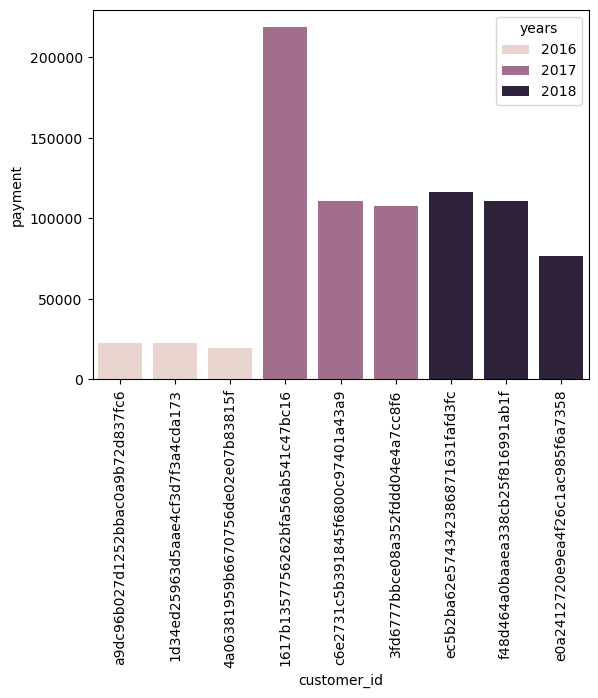

In [103]:
query = """select years, customer_id, payment, d_rank
from 
(select year(o.order_purchase_timestamp) as years, o.customer_id as customer_id, sum(pay.payment_value) as payment,
dense_rank() over(partition by year(o.order_purchase_timestamp) order by sum(pay.payment_value) desc) as d_rank from ecommerce.orders as o
inner join ecommerce.payments as pay
on pay.order_id = o.order_id
group by o.customer_id, years) as a	
where d_rank<=3;"""
# execute query for sql
cur.execute(query)
# fetch all data from database
data = cur.fetchall()
# show all fetched data
data

df = pd.DataFrame(data,columns=["years","customer_id","payment","rank"])
sns.barplot(x="customer_id",y="payment",data=df, hue="years")
plt.xticks(rotation=90)
plt.show()